In [1]:
import os
import glob
import gc
import random

from pathlib import Path

import numpy as np
import pandas as pd
import h5py

from scipy.sparse import csr_matrix
from pathlib import Path

import scipy

from scipy.stats import median_abs_deviation, percentileofscore
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import seaborn as sns

import anndata as ad
import scanpy.external as sce
import scanpy as sc

import pegasus as pg
from pegasusio import UnimodalData, MultimodalData
import scrublet as scr

from tqdm import tqdm

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

In [2]:
NOTARAS_SRR_FOLDERS = glob.glob('/mnt/sdb/scz_meta_analysis_processed/notaras_colak/star_outputs/*_Solo.out/')

In [3]:
## Functions Iterate Through Folders And Build H5 ##

def assemble_library_annata(srr_folder):
    
    ''' takes the path to an SRR_Solo.out/ and generates the anndata object '''
    
    #raw_path = Path(srr_folder) / "Gene/raw"
    raw_path = Path(srr_folder) / "Gene/filtered"
    adata = sc.read_mtx(raw_path / "matrix.mtx").T
    adata.var = pd.read_csv(raw_path / "features.tsv", delimiter="\t", header=None, names=['gene_symbols', 'assay'])
    adata.obs = pd.read_csv(raw_path / "barcodes.tsv", header=None, index_col=0, names=['barcodes'])
    adata.obs_names = [srr_folder.split('/')[-2].split('_')[0] + '_' + obs_name for obs_name in adata.obs_names] 
    adata.obs['library'] = srr_folder.split('/')[-2].split('_')[0]
    
    return adata

def concatenate_libraries(srr_folder_list):

    library_list = []
    
    for srr_folder in tqdm(srr_folder_list):    
        library_list.append(assemble_library_annata(srr_folder))
        #print('Loaded {0}'.format(srr_folder.split('/')[-2].split('_')[0]))

    concatted = sc.concat(library_list, join='outer', label="library")
    concatted.var['feature_types'] = 'Gene Expression'
    
    return concatted

In [4]:
Y_CHR_GENES = [
    "SRY",       # sex determining region Y :contentReference[oaicite:1]{index=1}
    "ZFY",       # zinc finger protein, Y‑linked :contentReference[oaicite:2]{index=2}
    "RPS4Y1",    # ribosomal protein S4, Y‑linked 1 :contentReference[oaicite:3]{index=3}
    "AMELY",     # amelogenin, Y‑linked :contentReference[oaicite:4]{index=4}
    "TSPY1",     # testis specific protein, Y‑encoded 1 :contentReference[oaicite:5]{index=5}
    "BPY2",      # basic charge Y‑linked 2 :contentReference[oaicite:6]{index=6}
    "UTY",       # ubiquitously transcribed tetratricopeptide repeat, Y‑linked :contentReference[oaicite:7]{index=7}
    "DDX3Y",     # DEAD‑box helicase 3, Y‑linked :contentReference[oaicite:8]{index=8}
    "USP9Y",     # ubiquitin specific peptidase 9 Y‑linked :contentReference[oaicite:9]{index=9}
    "RBMY1A1",   # RNA binding motif protein Y, family 1 A1 :contentReference[oaicite:10]{index=10}
    "CDY1",      # chromodomain protein Y‑linked 1 :contentReference[oaicite:11]{index=11}
    "CDY2A",     # chromodomain protein Y‑linked 2A :contentReference[oaicite:12]{index=12}
    "EIF1AY",    # eukaryotic translation initiation factor 1A Y‑linked :contentReference[oaicite:13]{index=13}
    # Pseudoautosomal region genes (present on both X and Y):
    "PAR1_PLCXD1",   # phosphatidylinositol specific phospholipase C X domain containing 1 (PAR1) :contentReference[oaicite:14]{index=14}
    "PAR1_GTPBP6",   # GTP binding protein 6 (PAR1) :contentReference[oaicite:15]{index=15}
    # Miscellaneous/other Y‑linked loci:
    "XGY1",      # XG Y‑linked 1 (pseudogene) :contentReference[oaicite:16]{index=16}
    # Additional annotated or reported Y‑linked genes:
    "VCY",       # variable charge Y‑linked (gene family) :contentReference[oaicite:17]{index=17}
    "PCDH11Y",   # protocadherin 11 Y‑linked :contentReference[oaicite:18]{index=18}
    "TGIF2LY",   # TGFB induced factor homeobox 2 like, Y‑linked :contentReference[oaicite:19]{index=19}
    "OFD1P1Y",   # OFD1 pseudogene 1 Y‑linked :contentReference[oaicite:20]{index=20}
]

In [5]:
notaras_adata = concatenate_libraries(NOTARAS_SRR_FOLDERS)

notaras_adata.obs['Run'] = [i.split('_')[0] for i in notaras_adata.obs_names]

notaras_adata.obs['barcodes'] = notaras_adata.obs_names

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.82it/s]


In [6]:
glob.glob('/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/GEO_files/*')

## note: GEO Files do not contain extra metadata ##

['/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/GEO_files/GSM5599215_S2_10xfiltered_feature_count_matrix.csv.bz2',
 '/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/GEO_files/GSM5599212_C3_10xfiltered_feature_count_matrix.csv.bz2',
 '/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/GEO_files/GSM5599213_C4_10xfiltered_feature_count_matrix.csv.bz2',
 '/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/GEO_files/GSM5599210_C1_10xfiltered_feature_count_matrix.csv.bz2',
 '/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/GEO_files/GSM5599211_C2_10xfiltered_feature_count_matrix.csv.bz2',
 '/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/GEO_files/GSM5599214_S1_10xfiltered_feature_count_matrix.csv.bz2',
 '/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/GEO_files/GSM5599216_S3_10xfiltered_feature_count_matrix.csv.bz2']

In [7]:
glob.glob('/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/*')

['/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/tmp',
 '/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/raw_data',
 '/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/fastq',
 '/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/metadata',
 '/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/GEO_files']

In [8]:
## Merge SRA Metadata ##

notaras_sra_metadata = pd.read_csv('/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/metadata/Notaras_SRA_RunTable.csv')

notaras_sra_metadata_essential = notaras_sra_metadata[['Run', 'BioProject', 'BioSample', 'disease_state', 
                                                       'Donor', 'Experiment', 'GEO_Accession (exp)', 'Instrument',
                                                       'ReleaseDate', 'create_date','Sample Name', 'source_name', 'SRA Study']]

notaras_adata.obs = notaras_adata.obs.merge(notaras_sra_metadata_essential, left_on='Run', right_on='Run', how='left')

notaras_adata.obs.index = notaras_adata.obs['barcodes']

notaras_adata.obs['Donor'] = notaras_adata.obs['Donor'].str.strip(';')

In [9]:
## Map NCBI Gene Names w/Prasanth's File ##

# load prasanth's annotation file
prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')

# merge prasanth's gene info into the var dataframe
notaras_adata.var['ensembl_gene_id'] = notaras_adata.var.index
#del notaras_adata.var['gene_name']
notaras_adata.var = notaras_adata.var.merge(prasanth_annot, left_on='ensembl_gene_id', right_on='ensembl_gene_id', how='left')
notaras_adata.var.chromosome_name = notaras_adata.var.chromosome_name.astype('str')

# fix gene name that is NaN
notaras_adata.var.loc[notaras_adata.var['hgnc_symbol'].isna(),'hgnc_symbol'] = notaras_adata.var.loc[notaras_adata.var['hgnc_symbol'].isna(),'ensembl_gene_id']

#reset the index as the hgnc_symbol
notaras_adata.var.index = notaras_adata.var['hgnc_symbol']
notaras_adata.var.index.name = None

#some ensembls map to same hgnc so we make them unique
notaras_adata.var_names_make_unique(join='#')

gc.collect()

/tmp/ipykernel_2585530/3771626602.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')


56215

In [10]:
## Donor Metadata From Supplementary Table 2 of Paper ##

notaras_donor_metadata = pd.read_csv('/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/metadata/Notaras_Donor_Metadata.csv')

notaras_adata.obs = notaras_adata.obs.merge(notaras_donor_metadata, 
                                            left_on='Donor', 
                                            right_on='NIH iPSC Scz Line', how='left').set_index('barcodes')

notaras_adata.obs['Sex'] = notaras_adata.obs['Sex'].astype('str')

In [11]:
print(notaras_adata.obs.shape[0])
print(notaras_adata.obs['Sex'].value_counts())

## Note of of the Donor IDs don't have a Sex ##
# We will need to Impute Later ##

122921
Sex
Male    63857
nan     59064
Name: count, dtype: int64


In [12]:
## Remove Duplicate Barcodes ##

print(notaras_adata.obs_names.duplicated(keep=False).any())
print(notaras_adata.var_names.duplicated(keep=False).any())

# None

False
False


In [13]:
## Set Up QC Metrics ##

# filter on robust genes
# annotate_robust_genes_scanpy(integrated, percent_cells=0.05)
pg.identify_robust_genes(notaras_adata, percent_cells=0.05)
notaras_adata = notaras_adata[:,notaras_adata.var['robust']].copy()
gc.collect()

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
notaras_adata.var["mt"] = notaras_adata.var_names.str.startswith("MT-")
# ribosomal genes
notaras_adata.var["ribo"] = notaras_adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
notaras_adata.var["hb"] = notaras_adata.var_names.str.contains("^HB[^(P)]")

# add protein_coding genes
notaras_adata.var['protein_coding'] = notaras_adata.var['gene_biotype'].apply(lambda x: True if 'protein_coding' == x else False)
notaras_adata.var['protein_coding'] = notaras_adata.var['protein_coding'].astype('bool')

# define mitocarta_genes
mitocarta_df = pd.read_csv('/home/deepak/datasets/annotations/Human.MitoCarta3.0.csv')
notaras_adata.var['mitocarta'] = [True if x in list(mitocarta_df['Symbol']) else False for x in notaras_adata.var.index]

# define robust_protein_coding genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
notaras_adata.var['robust_protein_coding'] = notaras_adata.var['robust'] & notaras_adata.var['protein_coding']
notaras_adata.var.loc[notaras_adata.var.ribo, 'robust_protein_coding'] = False
notaras_adata.var.loc[notaras_adata.var.mt, 'robust_protein_coding'] = False
notaras_adata.var.loc[notaras_adata.var.mitocarta, 'robust_protein_coding'] = False

# define robust_protein_coding_autosome genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
notaras_adata.var['autosome'] = notaras_adata.var.chromosome_name.isin([str(i) for i in range(1,23)])
notaras_adata.var['robust_protein_coding_autosome'] = notaras_adata.var['robust_protein_coding'] & notaras_adata.var['autosome'] 

2026-01-27 09:11:21,385 - pegasus.tools.preprocessing - INFO - After filtration, 25968/33538 genes are kept. Among 25968 genes, 17606 genes are robust.
2026-01-27 09:11:21,386 - pegasus.tools.preprocessing - INFO - Function 'identify_robust_genes' finished in 0.61s.


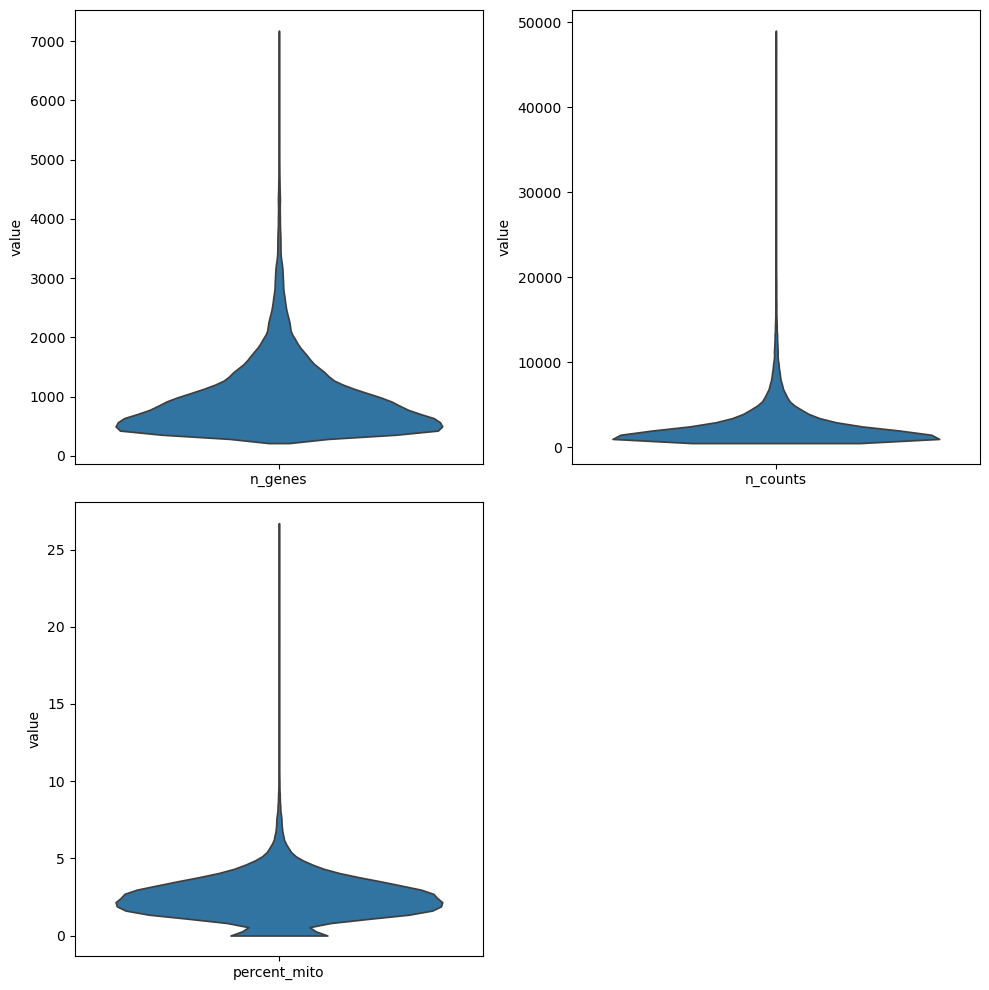

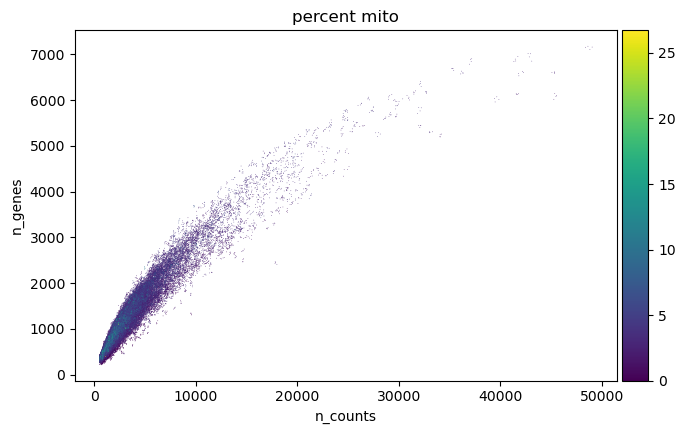

The 99th percentile all sample genes/cell is: 2254.0
The 99th percentile all sample total counts/cell is: 7127.0
The 99th percentile all sample mitochondrial % /cell is: 4.801097393035889


In [14]:
## Plot QC Metrics ##

# QC by counts #
# convert to pegasus unimodal object
notaras_adata = UnimodalData(notaras_adata)
pg.qc_metrics(notaras_adata, mito_prefix='MT-')

# Create a figure with 3 subplots

# convert back for plotting to scanpy anndata
notaras_adata = notaras_adata.to_anndata()
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
sc.pl.violin(notaras_adata, "n_genes", ax=axes[0], show=False, stripplot=False)
sc.pl.violin(notaras_adata, "n_counts", ax=axes[1], show=False, stripplot=False)
sc.pl.violin(notaras_adata, "percent_mito", ax=axes[2], show=False, stripplot=False)
fig.delaxes(axes[3])
plt.tight_layout()

sc.pl.scatter(notaras_adata, "n_counts", "n_genes", color="percent_mito")

print('The 99th percentile all sample genes/cell is: {0}'.format(np.percentile(notaras_adata.obs['n_genes'], 95)))

print('The 99th percentile all sample total counts/cell is: {0}'.format(np.percentile(notaras_adata.obs['n_counts'], 95)))

print('The 99th percentile all sample mitochondrial % /cell is: {0}'.format(np.percentile(notaras_adata.obs['percent_mito'], 95)))

n_UMIs lower: 434 upper: 7770
n_genes lower: 253 upper: 2601


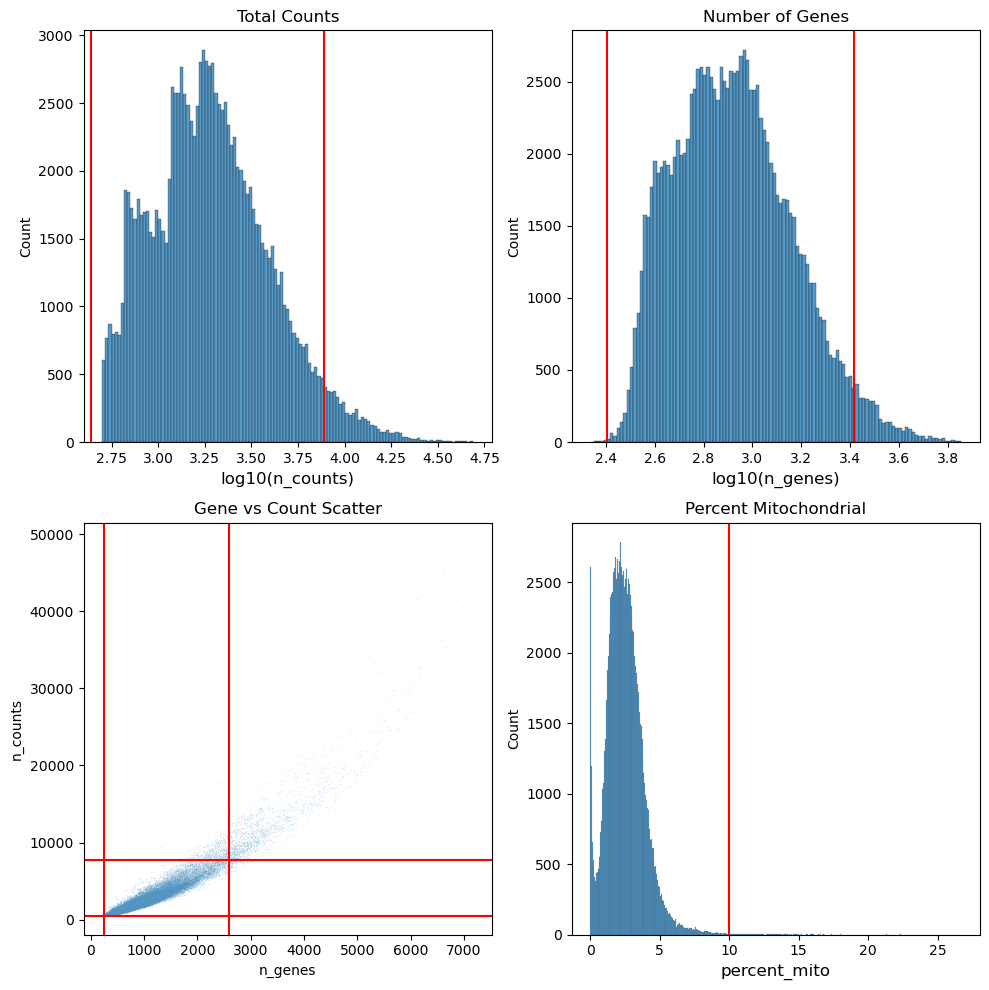

In [15]:
## Visualizating QC Cutoffs ##

MAD = 3

def qc_boundary(counts, k=MAD):
    x = np.log1p(counts)
    mad = median_abs_deviation(x)
    return np.exp(np.median(x) - k*mad), np.exp(np.median(x) + k*mad)

### nUMI and nGene QCs
n_counts_lower, n_counts_upper = qc_boundary(notaras_adata.obs.n_counts, k=MAD)
print('n_UMIs lower: %d upper: %d' % (n_counts_lower, n_counts_upper))

n_genes_lower, n_genes_upper = qc_boundary(notaras_adata.obs.n_genes, k=MAD)
print('n_genes lower: %d upper: %d' % (n_genes_lower, n_genes_upper))

## Plot Changes to Counts and Genes/Cell Distributions ##

fig, axs = plt.subplots(2, 2, figsize=(10, 10))  # 2x2 grid, adjust size as needed

# Plot 1: log10(n_counts)
sns.histplot(np.log10(notaras_adata.obs.n_counts), ax=axs[0, 0])
axs[0, 0].axvline(np.log10(n_counts_lower), color='red')
axs[0, 0].axvline(np.log10(n_counts_upper), color='red')
axs[0, 0].set_xlabel('log10(n_counts)', fontsize=12)
axs[0, 0].set_title("Total Counts")

# Plot 2: log10(n_genes)
sns.histplot(np.log10(notaras_adata.obs.n_genes), ax=axs[0, 1])
axs[0, 1].axvline(np.log10(n_genes_lower), color='red')
axs[0, 1].axvline(np.log10(n_genes_upper), color='red')
axs[0, 1].set_xlabel('log10(n_genes)', fontsize=12)
axs[0, 1].set_title("Number of Genes")

# Plot 3: scatter plot of n_genes vs n_counts
sns.scatterplot(x=notaras_adata.obs.n_genes, y=notaras_adata.obs.n_counts, alpha=0.5, s=0.1, ax=axs[1, 0])
axs[1, 0].axhline(n_counts_lower, color='red')
axs[1, 0].axhline(n_counts_upper, color='red')
axs[1, 0].axvline(n_genes_lower, color='red')
axs[1, 0].axvline(n_genes_upper, color='red')
axs[1, 0].set_xlabel('n_genes')
axs[1, 0].set_ylabel('n_counts')
axs[1, 0].set_title("Gene vs Count Scatter")

# Plot 4: percent_mito
sns.histplot(notaras_adata.obs.percent_mito, ax=axs[1, 1])
axs[1, 1].axvline(10, color='red')
axs[1, 1].set_xlabel('percent_mito', fontsize=12)
axs[1, 1].set_title("Percent Mitochondrial")

plt.tight_layout()
plt.show()

n_cells before QC: 122921
n_cells after QC: 122921
mean n_cells before QC 3073.025
mean n_cells after QC 3073.025


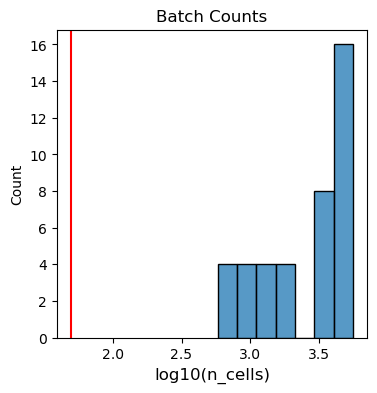

remove 0 batches that have cells less than 50


In [16]:
## Minimum Cell Cutoffs Based on Donor-Batches ##

args_min_n_cells = 50

n_cells_before_qc = notaras_adata.obs.library.value_counts().rename_axis('library').reset_index(name='counts')
n_cells_after_qc = notaras_adata.obs[notaras_adata.obs.passed_qc].library.value_counts().rename_axis('library').reset_index(name='counts')

print('n_cells before QC:', np.sum(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
print('n_cells after QC:', np.sum(n_cells_after_qc[n_cells_after_qc.counts>0].counts))

print('mean n_cells before QC', np.mean(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
print('mean n_cells after QC', np.mean(n_cells_after_qc[n_cells_after_qc.counts>0].counts))

# Plot Distribution of Donor-Batches on Being Greater than Zero
plt.figure(figsize=(4, 4))
plt.title('Batch Counts')
sns.histplot(np.log10(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
plt.axvline(np.log10(args_min_n_cells), color='red')
plt.xlabel('log10(n_cells)', fontsize=12)
plt.show()

### n_cells QC

#identify donor-batches with less than 50 cells of contribution
n_cells_outlier = list(n_cells_after_qc[n_cells_after_qc.counts<args_min_n_cells].library)
# set these to have failed QC as well
notaras_adata.obs.loc[notaras_adata.obs.library.isin(n_cells_outlier),'passed_qc'] = False
print('remove {0} batches that have cells less than {1}'.format(len(n_cells_outlier), args_min_n_cells))

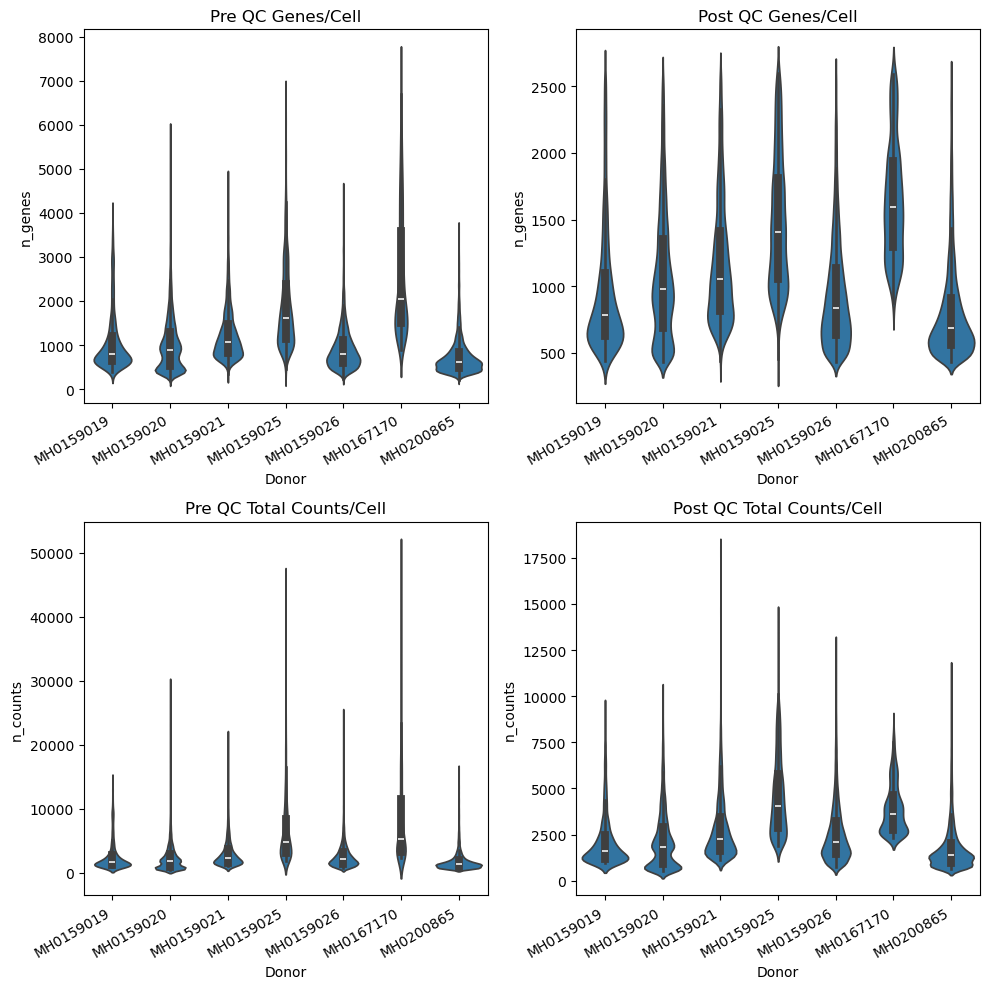

In [17]:
## Trialing QC Cutoffs Before and After ##

## Boolean Cutoffs for UMIs and Genes/Cell ##

counts_filter = (n_counts_lower < notaras_adata.obs.n_genes) & (notaras_adata.obs.n_genes < n_counts_upper)
genes_filter = (n_genes_lower < notaras_adata.obs.n_genes) & (notaras_adata.obs.n_genes < n_genes_upper)

# Plot Changes With Violins 

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
sns.violinplot(data=notaras_adata.obs, y='n_genes', x='Donor', ax=axes[0])
axes[0].set_title('Pre QC Genes/Cell')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=notaras_adata.obs[counts_filter & genes_filter], x='Donor', y='n_genes', ax=axes[1])
axes[1].set_title('Post QC Genes/Cell')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=notaras_adata.obs, y='n_counts', x='Donor', ax=axes[2])
axes[2].set_title('Pre QC Total Counts/Cell')
plt.setp(axes[2].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=notaras_adata.obs[notaras_adata.obs.passed_qc & genes_filter], x='Donor', y='n_counts', ax=axes[3])
axes[3].set_title('Post QC Total Counts/Cell')
plt.setp(axes[3].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [18]:
notaras_adata.obs['Run'].value_counts().shape[0]

40

In [19]:
notaras_adata.obs['Run'].value_counts().shape[0]/2

20.0

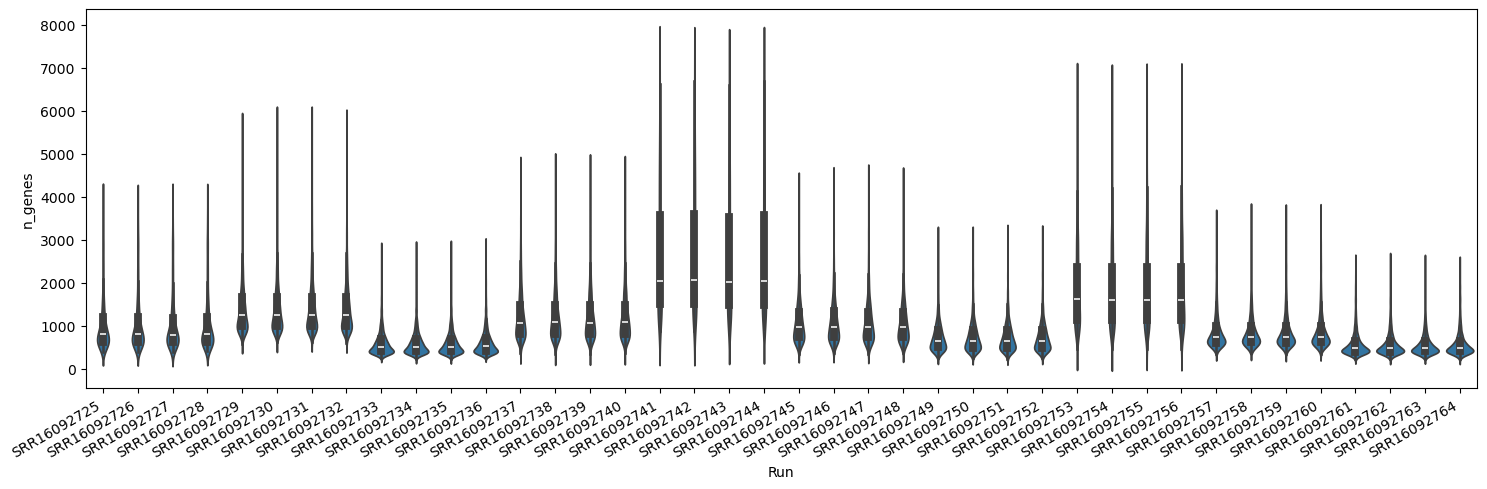

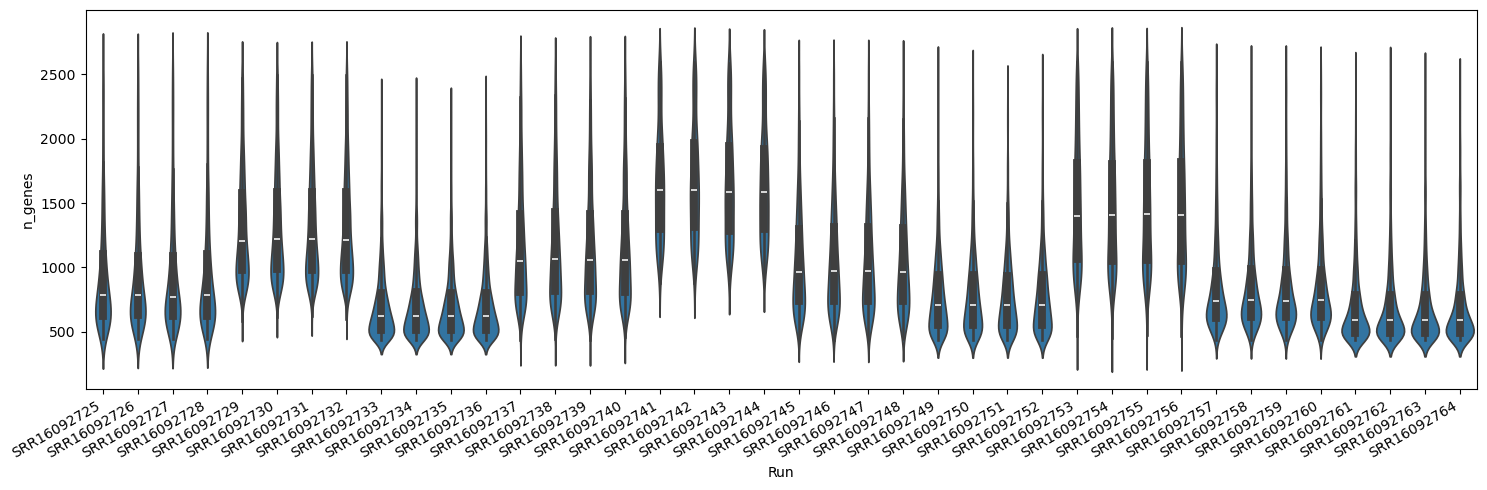

In [20]:
plt.figure(figsize=(15,5))
sns.violinplot(data=notaras_adata.obs, x='Run', y='n_genes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.figure(figsize=(15,5))
sns.violinplot(data=notaras_adata.obs[counts_filter & genes_filter], x='Run', y='n_genes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

In [21]:
## Remove Cells That Don't Meet Total Counts/Cell and Genes/Cell Thresholds ##

notaras_adata = MultimodalData(UnimodalData(notaras_adata, modality="rna"))

#notaras_adata = UnimodalData(notaras_adata)
pg.qc_metrics(notaras_adata, 
              min_genes=n_genes_lower, max_genes=n_genes_upper,
              min_umis=n_counts_lower, max_umis=n_counts_upper,
              mito_prefix='MT-', percent_mito=10)

pg.filter_data(notaras_adata)
gc.collect()
notaras_adata = notaras_adata.to_anndata()

2026-01-27 09:11:28,655 - pegasusio.qc_utils - INFO - After filtration, 117392 out of 122921 cell barcodes are kept in UnimodalData object unknown-rna.
2026-01-27 09:11:28,656 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 0.29s.


In [22]:
## Filter Cells and Genes With Raw Cutoffs #

# store raw counts in layer
notaras_adata.layers["raw_counts"] = notaras_adata.X

# Note: No cells fail this cutoff affter using MAD based filtration
print((notaras_adata.obs.n_genes < 100).sum())
print((notaras_adata.var.n_cells < 20).any())

# Doing This For Completeness
sc.pp.filter_cells(notaras_adata, min_genes=100)
sc.pp.filter_genes(notaras_adata, min_cells=20)

0
False


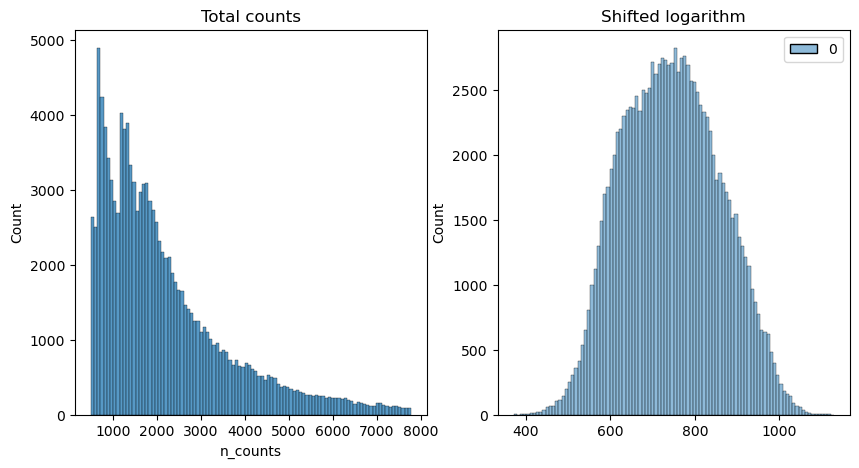

In [23]:
## Log Normalization ##

# normalize 
scales_counts = sc.pp.normalize_total(notaras_adata, layer='raw_counts', target_sum=None, inplace=False)

# log1p transform
notaras_adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

# set X as log1p normed counts
notaras_adata.X = notaras_adata.layers["log1p_norm"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(notaras_adata.obs["n_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(notaras_adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

2026-01-27 09:11:32,561 - pegasus.tools.utils - INFO - Loaded signatures from GMT file /home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pegasus/data_files/cell_cycle_human.gmt.
2026-01-27 09:11:32,564 - pegasus.tools.signature_score - INFO - Signature G1/S: 43 out of 43 genes are used in signature score calculation.
2026-01-27 09:11:32,752 - pegasus.tools.signature_score - INFO - Signature G2/M: 54 out of 54 genes are used in signature score calculation.
2026-01-27 09:11:33,013 - pegasus.tools.signature_score - INFO - Function 'calc_signature_score' finished in 0.86s.
2026-01-27 09:11:40,596 - pegasus.tools.preprocessing - INFO - Function 'pca' finished in 5.21s.


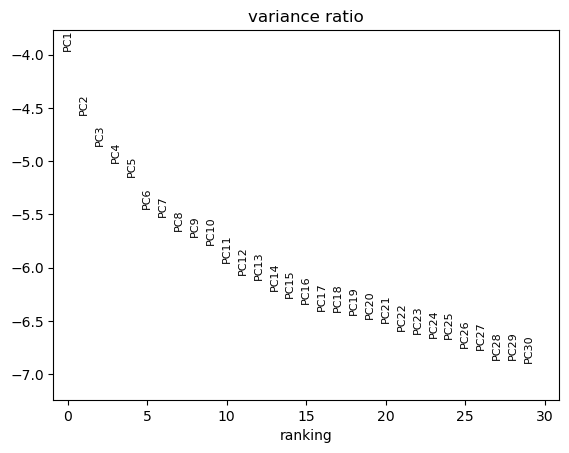

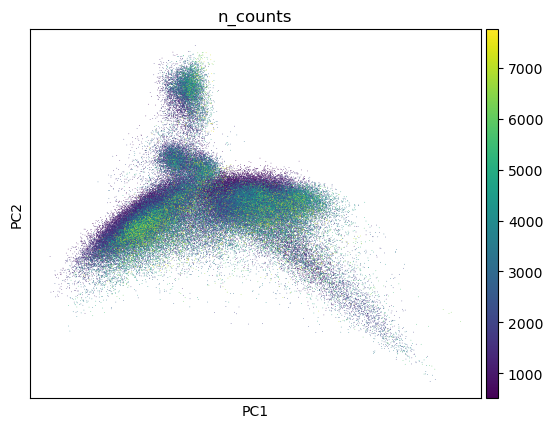

There is 9.910579917083448 variance explained by these components
2026-01-27 09:11:41,180 - pegasus.tools.preprocessing - INFO - Function 'regress_out' finished in 0.12s.
2026-01-27 09:11:41,182 - pegasus.tools.batch_correction - INFO - Start integration using Harmony.
	Initialization is completed.
	Completed 1 / 20 iteration(s).
	Completed 2 / 20 iteration(s).
	Completed 3 / 20 iteration(s).
	Completed 4 / 20 iteration(s).
	Completed 5 / 20 iteration(s).
	Completed 6 / 20 iteration(s).
	Completed 7 / 20 iteration(s).
Reach convergence after 7 iteration(s).
2026-01-27 09:12:08,735 - pegasus.tools.batch_correction - INFO - Function 'run_harmony' finished in 27.55s.
2026-01-27 09:12:31,714 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 22.98s.
2026-01-27 09:12:34,845 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 3.13s.
2026-01-27 09:12:37,632 - pegasus.tools.graph_operations - INFO - Function 'construct_graph'

/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Jan 27 09:12:55 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Jan 27 09:13:41 2026 Finished embedding
2026-01-27 09:13:41,444 - pegasus.tools.visualization - INFO - Function 'umap' finished in 48.29s.


In [24]:
# Calculate Highly Variable Genes (not using deviance) ##

if not isinstance(notaras_adata, UnimodalData):
    notaras_adata = UnimodalData(notaras_adata)

## ROUND 0 ##

# calc score requires a float downcast for some reason
notaras_adata.X = notaras_adata.X.astype('float32')
pg.calc_signature_score(notaras_adata, 'cell_cycle_human')

# calculate HVGs on a protein_coding_autosomal only gene list
notaras_hvg = notaras_adata[:,notaras_adata.var.robust_protein_coding_autosome].copy()
notaras_hvg = notaras_hvg.to_anndata()
hvg = sc.pp.highly_variable_genes(notaras_hvg, layer='log1p_norm', n_top_genes=3000, inplace=False, subset=False)
hvg_list = notaras_hvg.var.index[hvg.highly_variable].tolist()
del notaras_hvg
gc.collect()

# apply that HVG list to your original anndata object
notaras_adata.var['highly_variable_features'] = False
notaras_adata.var['highly_variable_features'] = notaras_adata.var.index.isin(hvg_list)

## Dimensionality Reduction ##

# PCA

if not isinstance(notaras_adata, UnimodalData):
    notaras_adata = UnimodalData(notaras_adata)

pg.pca(notaras_adata, n_components=30)
sc.pl.pca_variance_ratio(notaras_adata, n_pcs=30, log=True)
sc.pl.pca_scatter(notaras_adata.to_anndata(), color="n_counts")
plt.show()

print('There is {0} variance explained by these components'.format(notaras_adata.uns['pca']['variance_ratio'].sum()*100))

# # Regress Out ##

pg.regress_out(notaras_adata, ['n_counts', 'percent_mito'])

## Harmony  

pg.run_harmony(notaras_adata, batch=['Donor'], rep='pca_regressed', max_iter_harmony=20, n_comps=30)

# # UMAP

pg.neighbors(notaras_adata, rep='pca_regressed_harmony', use_cache=False, dist='l2', K=100, n_comps=30)
pg.leiden(notaras_adata, rep='pca_regressed_harmony', resolution=0.1, class_label='class')
pg.umap(notaras_adata, rep='pca_regressed_harmony', n_neighbors=15, rep_ncomps=30)
plt.show()

notaras_adata = notaras_adata.to_anndata()

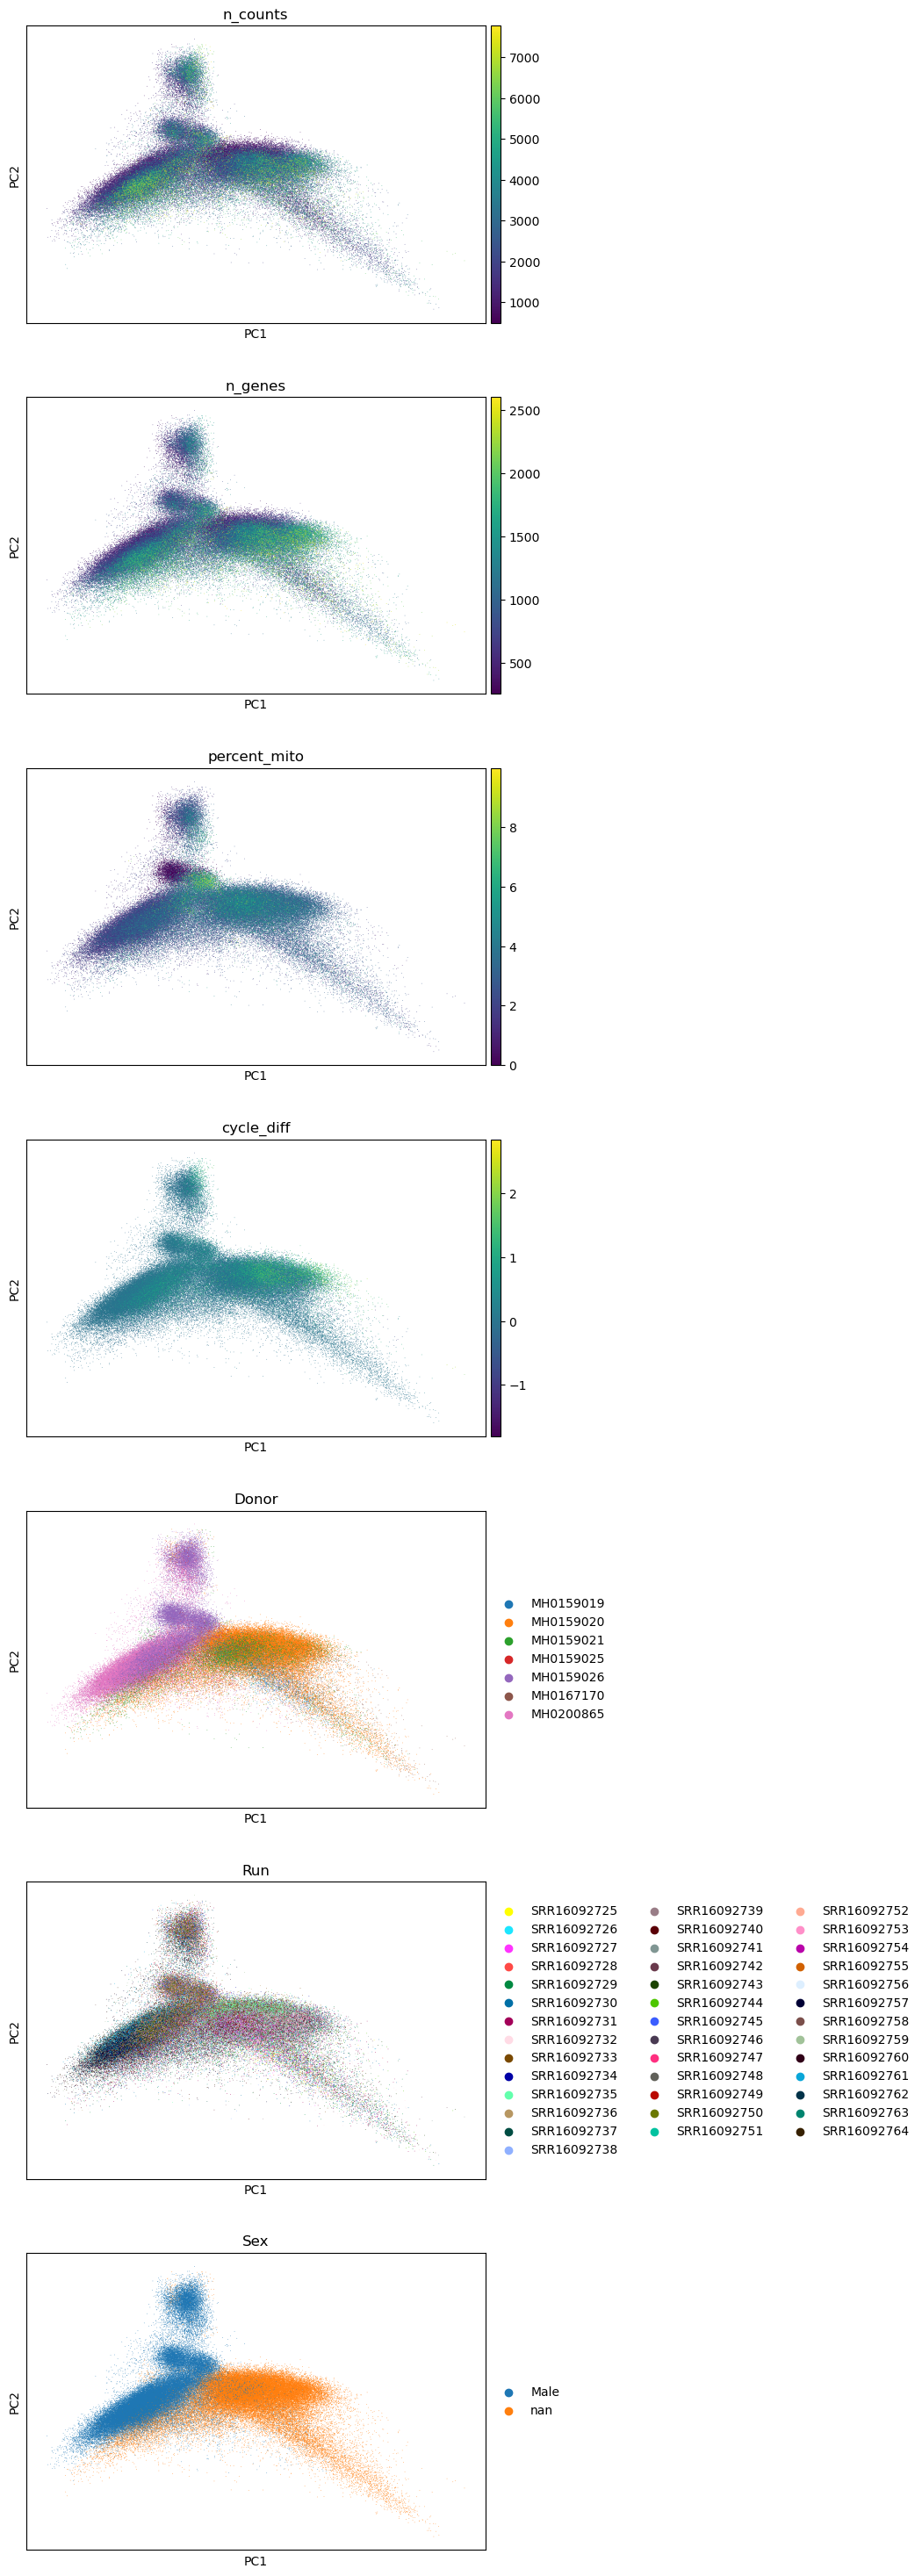

In [25]:
sc.pl.pca(notaras_adata, color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

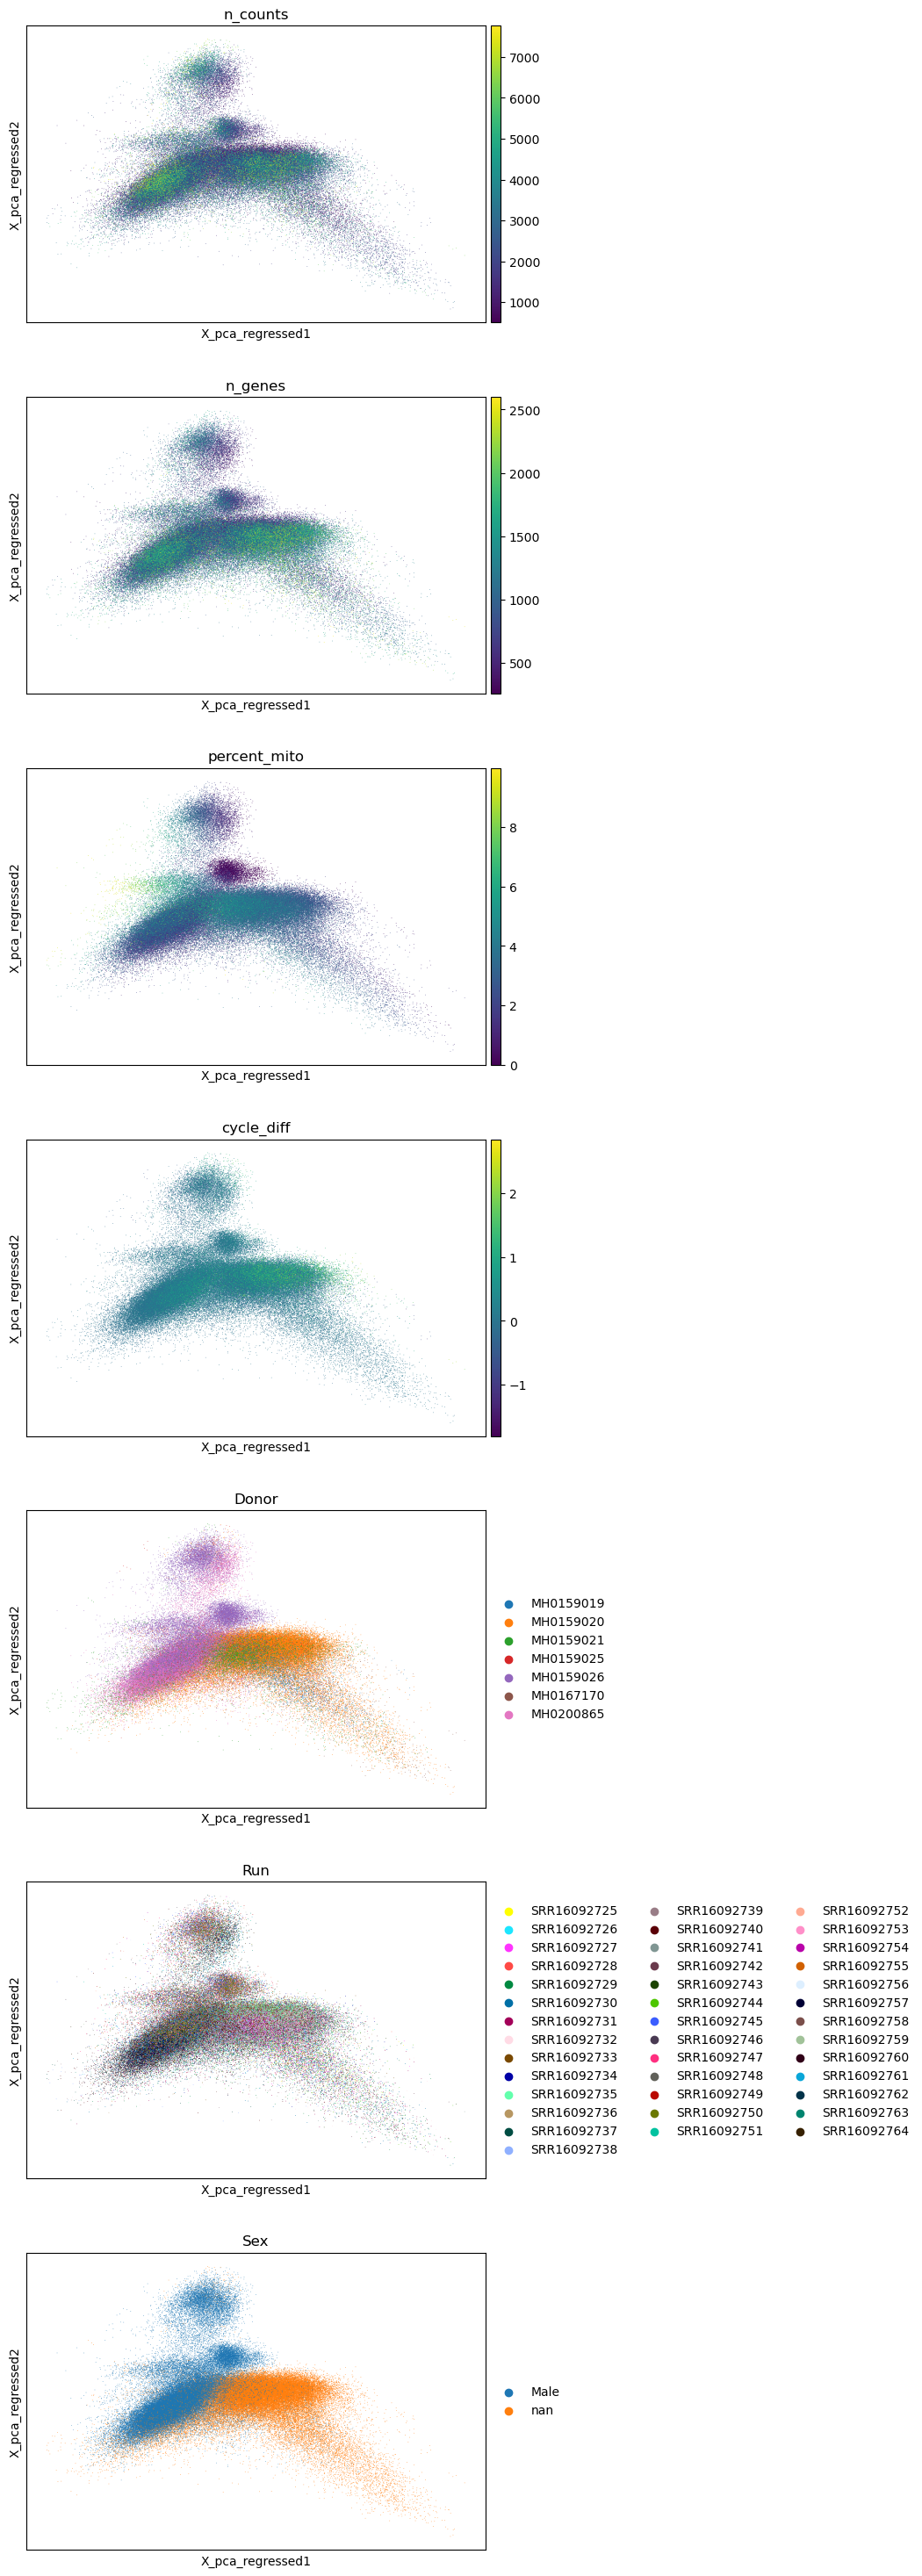

In [26]:
sc.pl.embedding(notaras_adata, basis='X_pca_regressed', 
                color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

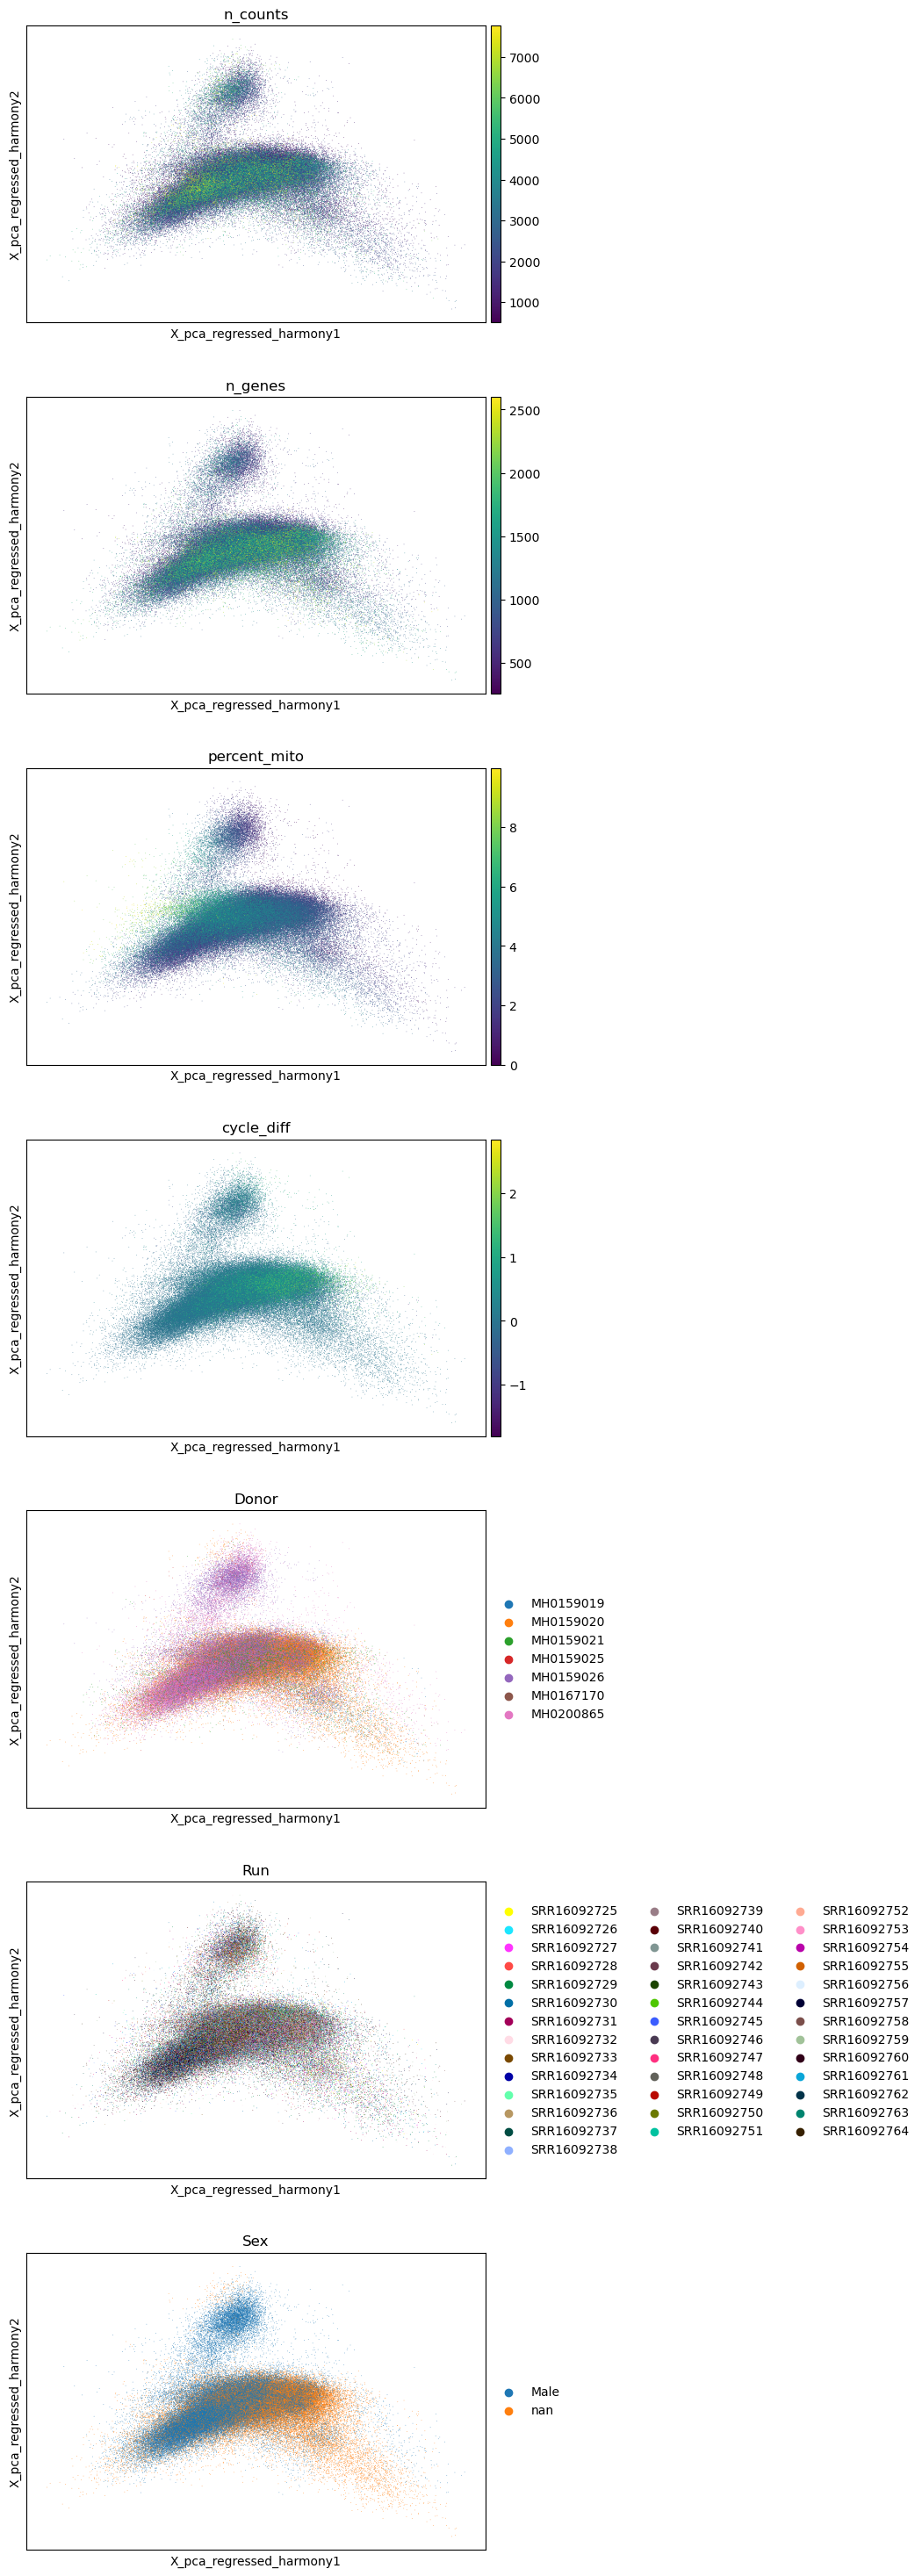

In [27]:
sc.pl.embedding(notaras_adata, basis='X_pca_regressed_harmony', 
                color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

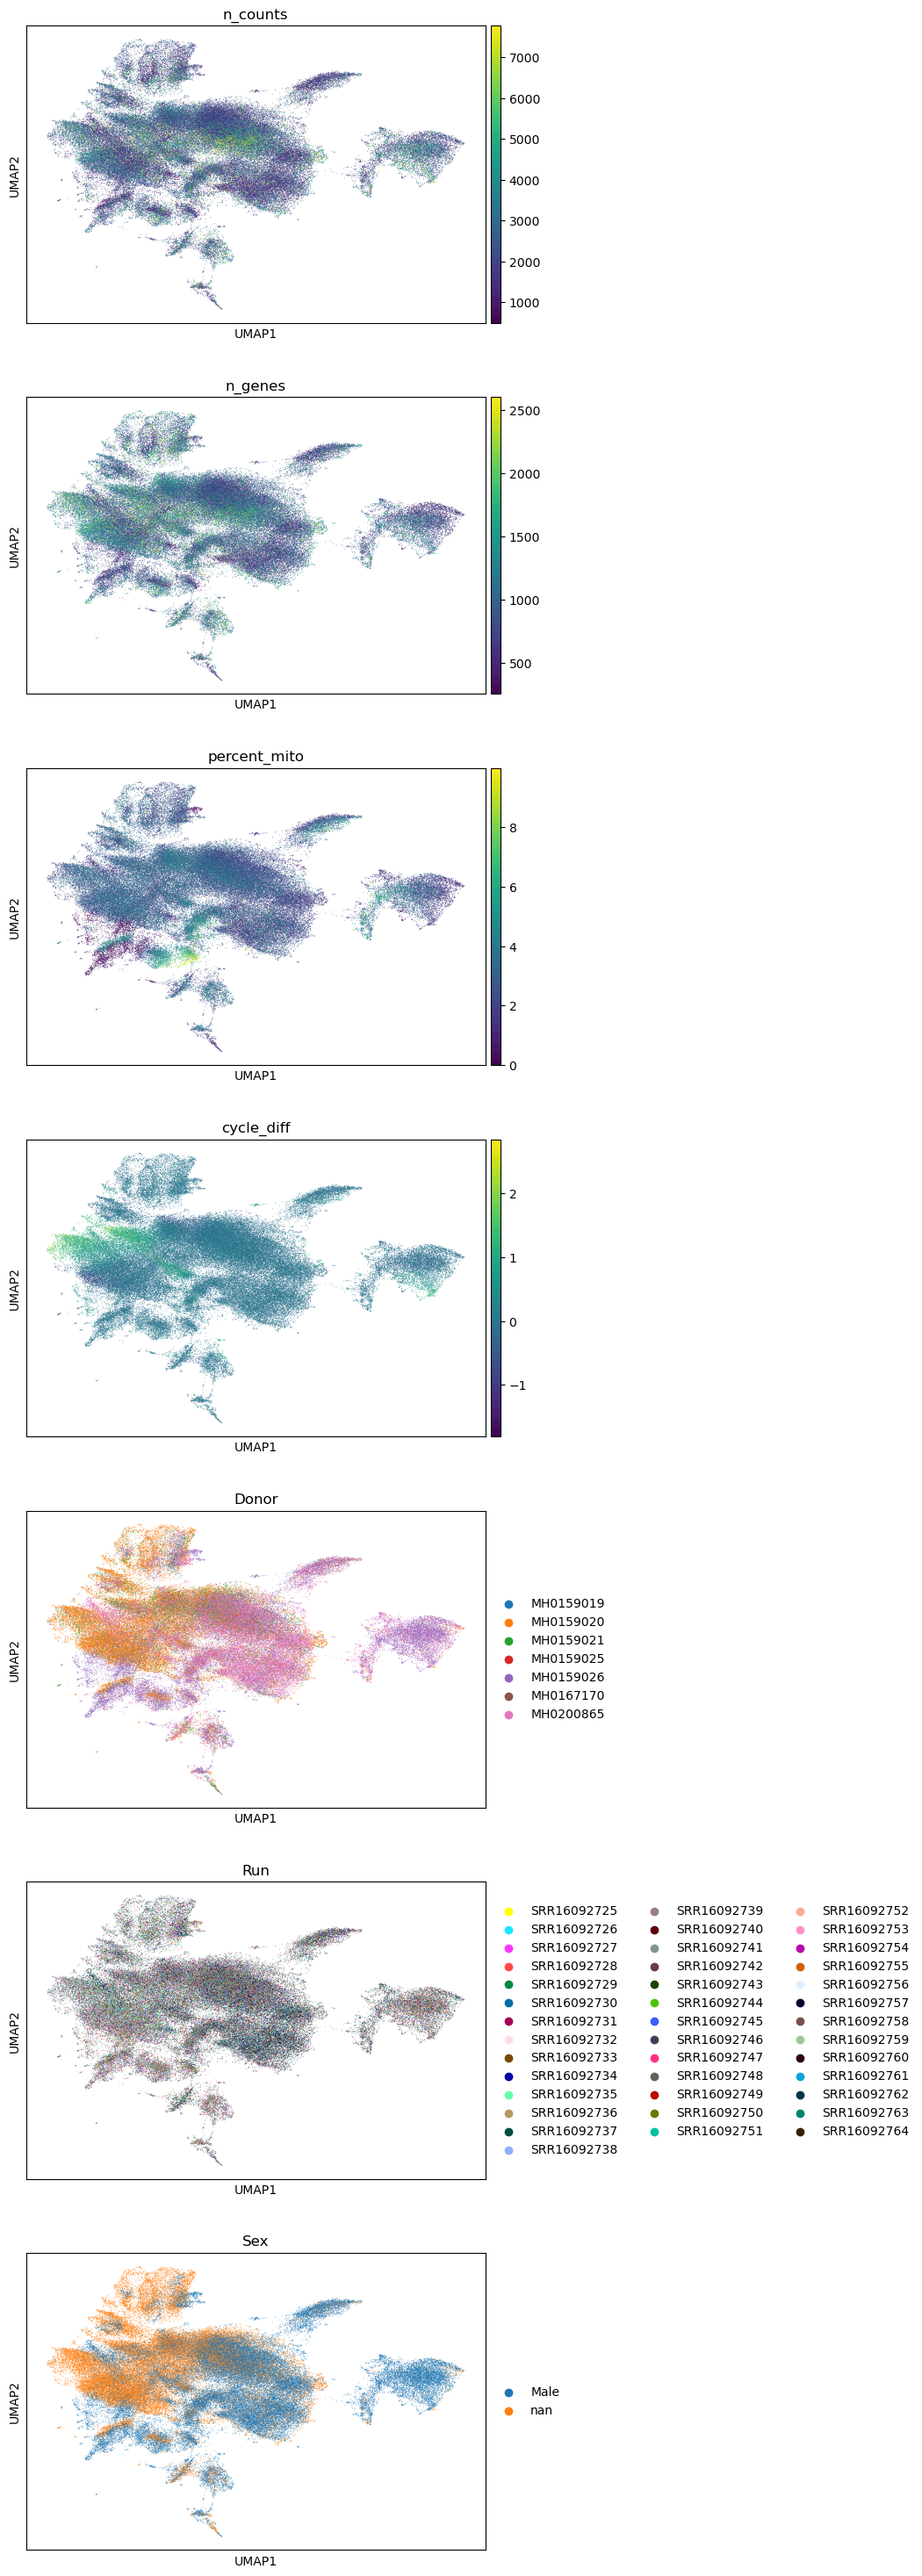

In [28]:
sc.pl.umap(notaras_adata, color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

In [29]:
notaras_y_matrix = notaras_adata[:,notaras_adata.var_names[notaras_adata.var_names.isin(Y_CHR_GENES)]].X.toarray()

notaras_y_df = pd.DataFrame(data=notaras_y_matrix, columns=notaras_adata.var_names[notaras_adata.var_names.isin(Y_CHR_GENES)],
          index=notaras_adata.obs_names)

notaras_y_df['Donor'] = notaras_adata[:,notaras_adata.var_names[notaras_adata.var_names.isin(Y_CHR_GENES)]].obs['Donor']

/tmp/ipykernel_2585530/1279449471.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.heatmap(notaras_y_df.groupby('Donor').mean())


<Axes: xlabel='featurekey', ylabel='Donor'>

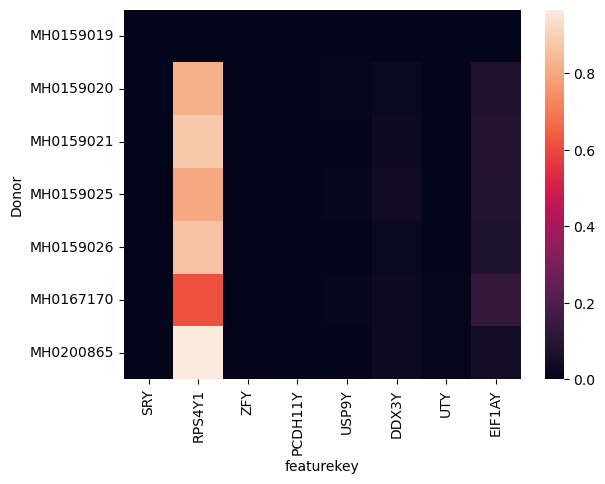

In [30]:
sns.heatmap(notaras_y_df.groupby('Donor').mean())

In [31]:
notaras_adata.obs[['Donor', 'Sex']].value_counts()

Donor      Sex 
MH0159020  nan     42321
MH0200865  Male    33958
MH0159026  Male    25078
MH0159021  nan      7751
MH0159019  nan      4434
MH0159025  Male     2451
MH0167170  nan      1399
Name: count, dtype: int64

In [32]:
## Looks as if MH0159020 MH0159021 MH0167170 are likely Male, and MH0159019 female ##

unknown_sex_dict = {'MH0159020': 'Imputed Male', 'MH0159021': 'Imputed Male', 
                    'MH0159019':'Imputed Female', 'MH0167170':'Imputed Male'}

notaras_adata.obs['Imputed_Sex'] = notaras_adata.obs.apply(lambda row: unknown_sex_dict.get(row['Donor'], row['Sex']), axis=1)

notaras_adata.obs['Imputed_Sex'].value_counts()

Imputed_Sex
Male              61487
Imputed Male      51471
Imputed Female     4434
Name: count, dtype: int64

In [33]:
notaras_adata.X.astype

<bound method _data_matrix.astype of <Compressed Sparse Row sparse matrix of dtype 'float32'
	with 105004148 stored elements and shape (117392, 17606)>>

In [34]:
## Save Step ##

notaras_adata.write_h5ad(os.path.join('/mnt/sdb/scz_meta_analysis_processed/notaras_colak/anndata_objs/notaras_qc.h5ad'))